Imports and Data Loading

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
import joblib
import os
import sys

project_root = os.path.abspath('..')
src_path = os.path.join(project_root, 'src')

if src_path not in sys.path:
    sys.path.insert(0, src_path)

from heart_utils import setup_logger, ensure_dir

logger = setup_logger('Training')

X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()

logger.info(f"Training data loaded. Features: {X_train.shape[1]}, Samples: {X_train.shape[0]}")

2026-03-11 01:26:16,087 - Training - INFO - Training data loaded. Features: 13, Samples: 241
2026-03-11 01:26:16,087 - Training - INFO - Training data loaded. Features: 13, Samples: 241
2026-03-11 01:26:16,087 - Training - INFO - Training data loaded. Features: 13, Samples: 241


Model Benchmarking

In [26]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
}

results = {}

print("Starting Cross-Validation Benchmarking")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = cv_scores.mean()
    msg = f"{name} Mean CV Accuracy: {cv_scores.mean() * 100:.4f}%"
    print(msg)
    logger.info(msg)

best_model_name = max(results, key=results.get)
logger.info(f"Benchmark winner: {best_model_name}")

2026-03-11 01:27:50,309 - Training - INFO - Logistic Regression Mean CV Accuracy: 82.1599%
2026-03-11 01:27:50,309 - Training - INFO - Logistic Regression Mean CV Accuracy: 82.1599%
2026-03-11 01:27:50,309 - Training - INFO - Logistic Regression Mean CV Accuracy: 82.1599%


Starting Cross-Validation Benchmarking
Logistic Regression Mean CV Accuracy: 82.1599%


2026-03-11 01:27:50,615 - Training - INFO - Random Forest Mean CV Accuracy: 81.7262%
2026-03-11 01:27:50,615 - Training - INFO - Random Forest Mean CV Accuracy: 81.7262%
2026-03-11 01:27:50,615 - Training - INFO - Random Forest Mean CV Accuracy: 81.7262%
2026-03-11 01:27:50,625 - Training - INFO - KNN Mean CV Accuracy: 80.9269%
2026-03-11 01:27:50,625 - Training - INFO - KNN Mean CV Accuracy: 80.9269%
2026-03-11 01:27:50,625 - Training - INFO - KNN Mean CV Accuracy: 80.9269%
2026-03-11 01:27:50,626 - Training - INFO - Benchmark winner: Logistic Regression
2026-03-11 01:27:50,626 - Training - INFO - Benchmark winner: Logistic Regression
2026-03-11 01:27:50,626 - Training - INFO - Benchmark winner: Logistic Regression


Random Forest Mean CV Accuracy: 81.7262%
KNN Mean CV Accuracy: 80.9269%


Final Training and Feature Importance

2026-03-11 01:26:27,760 - Training - INFO - Applying Hyperparameter Tuning to Logistic Regression
2026-03-11 01:26:27,760 - Training - INFO - Applying Hyperparameter Tuning to Logistic Regression
2026-03-11 01:26:27,760 - Training - INFO - Applying Hyperparameter Tuning to Logistic Regression
2026-03-11 01:26:27,902 - Training - INFO - Best parameters for LR: {'C': 0.1, 'solver': 'lbfgs'}
2026-03-11 01:26:27,902 - Training - INFO - Best parameters for LR: {'C': 0.1, 'solver': 'lbfgs'}
2026-03-11 01:26:27,902 - Training - INFO - Best parameters for LR: {'C': 0.1, 'solver': 'lbfgs'}


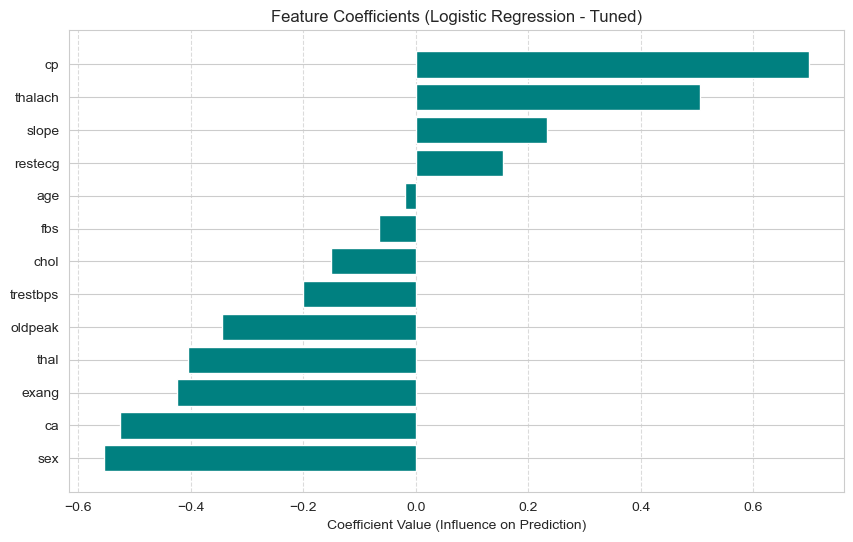

In [23]:
logger.info(f"Applying Hyperparameter Tuning to {best_model_name}")

if best_model_name == "Logistic Regression":
    # Tuning parameters: C (regularization strength) and solver
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear']
    }

    # We use GridSearchCV with scoring='recall' to prioritize finding sick patients
    grid_search = GridSearchCV(
        LogisticRegression(random_state=42, max_iter=1000),
        param_grid, cv=5, scoring='recall', verbose=0
    )
    grid_search.fit(X_train, y_train)

    final_model = grid_search.best_estimator_
    logger.info(f"Best parameters for LR: {grid_search.best_params_}")
else:
    # If another model won, fit it with default parameters for simplicity
    final_model = models[best_model_name]
    final_model.fit(X_train, y_train)

# Visualization of Feature Influence
if hasattr(final_model, 'coef_'):
    importance = final_model.coef_[0]
    features = X_train.columns
    indices = np.argsort(importance)

    plt.figure(figsize=(10, 6))
    plt.title(f'Feature Coefficients ({best_model_name} - Tuned)')
    plt.barh(range(len(indices)), importance[indices], color='teal', align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Coefficient Value (Influence on Prediction)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
elif hasattr(final_model, 'feature_importances_'):
    # Handling Random Forest importance if it wins
    importance = final_model.feature_importances_
    features = X_train.columns
    indices = np.argsort(importance)

    plt.figure(figsize=(10, 6))
    plt.title(f'Feature Importance ({best_model_name})')
    plt.barh(range(len(indices)), importance[indices], color='teal', align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.show()

Saving the Model

In [25]:
ensure_dir('../models')
model_path = '../models/trained_model.pkl'
joblib.dump(final_model, model_path)

logger.info(f"Tuned {best_model_name} model successfully saved to {model_path}")

2026-03-11 01:27:20,327 - Training - INFO - Tuned Logistic Regression model successfully saved to ../models/trained_model.pkl
2026-03-11 01:27:20,327 - Training - INFO - Tuned Logistic Regression model successfully saved to ../models/trained_model.pkl
2026-03-11 01:27:20,327 - Training - INFO - Tuned Logistic Regression model successfully saved to ../models/trained_model.pkl
